In [1]:
using Pkg
Pkg.activate("/home/gridsan/aligho/Github_Projects/JJDFTX.jl/")
ENV["JULIA_REVISE_POLL"]="1";
using Revise

In [2]:
using PyPlot, PyCall, Peaks, Statistics, JJDFTX, DelimitedFiles;

Your version of python is not linked to helper_scripts.py
Your version of python is not linked to the Atomic Simulation Environment


In [3]:
# Pyplot rcparams
rcParams = PyPlot.PyDict(PyPlot.matplotlib."rcParams")
rcParams["text.usetex"] = false;
mlines = pyimport("matplotlib").lines
# General method to give red-green-blue values for plotting
rgb(x, y, z) = [x, y, z] ./ 255

rgb (generic function with 1 method)

In [4]:
# Phonon calculations indicate that only the buckled B substitution lattices are stable
bn22bc_dir="./BN22BC"
bn22bc_buckled_dir="./BN22BC_Buckled"
bn33bc_dir="./BN33BC"
bn33bc_buckled_dir="./BN33BC_Buckled"
bn44bc_dir="./BN44BC"
bn44bc_buckled_dir="./BN44BC_Buckled"
bn22nc_dir="./BN22NC"
bn33nc_dir="./BN33NC"
bn44nc_dir="./BN44NC"
Ag_dir = "/home/gridsan/aligho/Plasmons/Plasmons_Paper/Substitutional_Defects/Argentene/3Dnew"
Argentene_dir = "/home/gridsan/aligho/Plasmons/Plasmons_Paper/Substitutional_Defects/Argentene/2Dnew"
graphene_dir = "./Graphene";

In [5]:
bn22bc_splits_lda_cnone, bn22bc_x_n_lda_cnone, bn22bc_splits_lda, bn22bc_x_n_lda, bn22bc_splits_pbe, bn22bc_x_n_pbe =
[col for col in eachcol(readdlm(bn22bc_dir*"/Doping/Exchange_Model.txt", ',')[2:end, :])];
bn22nc_splits_lda_cnone, bn22nc_x_n_lda_cnone, bn22nc_splits_lda, bn22nc_x_n_lda, bn22nc_splits_pbe, bn22nc_x_n_pbe =
[col for col in eachcol(readdlm(bn22nc_dir*"/Doping/Exchange_Model.txt", ',')[2:end, :])];

bn33bc_splits_lda_cnone, bn33bc_x_n_lda_cnone, bn33bc_splits_lda, bn33bc_x_n_lda, bn33bc_splits_pbe, bn33bc_x_n_pbe =
[col for col in eachcol(readdlm(bn33bc_dir*"/doping/Exchange_Model.txt", ',')[2:end, :])];
bn33nc_splits_lda_cnone, bn33nc_x_n_lda_cnone, bn33nc_splits_lda, bn33nc_x_n_lda, bn33nc_splits_pbe, bn33nc_x_n_pbe =
[col for col in eachcol(readdlm(bn33nc_dir*"/Doping/Exchange_Model.txt", ',')[2:end, :])];

bn44bc_splits_lda_cnone, bn44bc_x_n_lda_cnone, bn44bc_splits_lda, bn44bc_x_n_lda, bn44bc_splits_pbe, bn44bc_x_n_pbe =
[col for col in eachcol(readdlm(bn44bc_dir*"/Doping/Exchange_Model.txt", ',')[2:end, :])];
bn44nc_splits_lda_cnone, bn44nc_x_n_lda_cnone, bn44nc_splits_lda, bn44nc_x_n_lda, bn44nc_splits_pbe, bn44nc_x_n_pbe =
[col for col in eachcol(readdlm(bn44nc_dir*"/Doping/Exchange_Model.txt", ',')[2:end, :])];

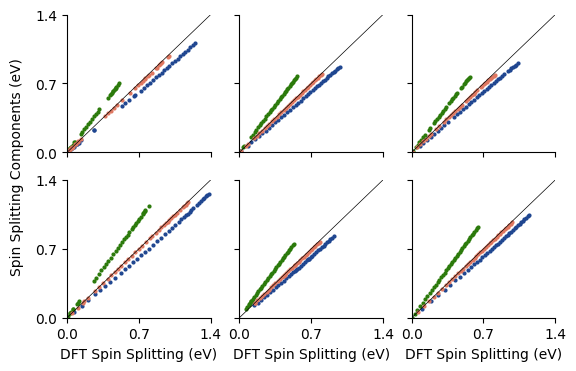

In [6]:
x = 0:0.01:1.4
has_spines = false
cm = 1/2.54
figure(figsize=(16*cm, 10*cm))
title_size = 10
label_size = 10
subplot(2, 3, 1)
gca().spines["top"].set_visible(has_spines)
gca().spines["right"].set_visible(has_spines)

#title("BN22BC", size=title_size)
dot_size = 4
linewidth = 0.5
pbe_color = rgb(31, 70, 144)
lda_color = rgb(43, 122, 11)
lda_cnone_color = rgb(223, 120, 97)
scatter(bn22bc_splits_pbe, bn22bc_x_n_pbe, label="PBE", color=pbe_color, s=dot_size)
scatter(bn22bc_splits_lda, bn22bc_x_n_lda, label="Perdew-Zunger LDA", color=lda_color, s=dot_size)
scatter(bn22bc_splits_lda_cnone, bn22bc_x_n_lda_cnone, label="Slater Exchange without Correlation", color=lda_cnone_color, s=dot_size)
plot(x, x, color="black", linewidth=linewidth)
xlim(0, 1.4)
ylim(0, 1.4)
yticks([0, 0.7, 1.4], ["0.0", "0.7", "1.4"], size=label_size)

xticks([0, 0.7, 1.4], ["", "", ""])
#plot(bn22bc_splits_pbe, bn22bc_splits_pbe, color="black")
xlabel("")
#xlabel("DFT Spin Splitting (eV)")
ylabel("Spin Splitting Components (eV)", size=label_size)
gca().yaxis.set_label_coords(-0.3, -.1)

subplot(2, 3, 4)
gca().spines["top"].set_visible(has_spines)
gca().spines["right"].set_visible(has_spines)
gca().spines["top"].set_visible(has_spines)
gca().spines["right"].set_visible(has_spines)

#title("BN22NC", size=title_size)
scatter(bn22nc_splits_pbe, bn22nc_x_n_pbe, label="PBE", color=pbe_color, s=dot_size)
scatter(bn22nc_splits_lda, bn22nc_x_n_lda, label="Perdew-Zunger LDA", color=lda_color, s=dot_size)
scatter(bn22nc_splits_lda_cnone, bn22nc_x_n_lda_cnone, label="Slater Exchange without Correlation", color=lda_cnone_color, s=dot_size)
plot(x, x, color="black", linewidth=linewidth)
xlim(0, 1.4)
ylim(0, 1.4)
#plot(bn22nc_splits_pbe, bn22nc_splits_pbe, color="black")
#xlabel("")
xticks([0, 0.7, 1.4], ["0.0", "0.7", "1.4"], size=label_size)
yticks([0, 0.7, 1.4], ["0.0", "0.7", "1.4"], size=label_size)
xlabel("DFT Spin Splitting (eV)", size=label_size)
#ylabel("Spin Splitting Components (eV)")

subplot(2, 3, 2)
gca().spines["top"].set_visible(has_spines)
gca().spines["right"].set_visible(has_spines)

#title("BN33BC", size=title_size)
scatter(bn33bc_splits_pbe, bn33bc_x_n_pbe, label="PBE", color=pbe_color, s=dot_size)
scatter(bn33bc_splits_lda, bn33bc_x_n_lda, label="Perdew-Zunger LDA", color=lda_color, s=dot_size)
scatter(bn33bc_splits_lda_cnone, bn33bc_x_n_lda_cnone, label="Slater Exchange without Correlation", color=lda_cnone_color, s=dot_size)
plot(x, x, color="black", linewidth=linewidth)
xlim(0, 1.4)
ylim(0, 1.4)
#plot(bn33bc_splits_pbe, bn33bc_splits_pbe, color="black")
xlabel("")
yticks([0, 0.7, 1.4], ["", "", ""])
xticks([0, 0.7, 1.4], ["", "", ""])

#xlabel("DFT Spin Splitting (eV)")
#ylabel("Spin Splitting Components (eV)")

subplot(2, 3, 5)
gca().spines["top"].set_visible(has_spines)
gca().spines["right"].set_visible(has_spines)

#title("BN33NC", size=title_size)
scatter(bn33nc_splits_pbe, bn33nc_x_n_pbe, label="PBE", color=pbe_color, s=dot_size)
scatter(bn33nc_splits_lda, bn33nc_x_n_lda, label="Perdew-Zunger LDA", color=lda_color, s=dot_size)
scatter(bn33nc_splits_lda_cnone, bn33nc_x_n_lda_cnone, label="Slater Exchange without Correlation", color=lda_cnone_color, s=dot_size)
xlim(0, 1.4)
ylim(0, 1.4)
xticks([0, 0.7, 1.4], ["0.0", "0.7", "1.4"], size=label_size)
yticks([0, 0.7, 1.4], ["", "", ""])

plot(x, x, color="black", linewidth=linewidth)
#plot(bn33nc_splits_pbe, bn33nc_splits_pbe, color="black")
#xlabel("")
xlabel("DFT Spin Splitting (eV)", size=label_size)

subplot(2, 3, 3)

gca().spines["top"].set_visible(has_spines)
gca().spines["right"].set_visible(has_spines)

#title("BN44BC", size=title_size)
scatter(bn44bc_splits_pbe, bn44bc_x_n_pbe, label="PBE", color=pbe_color, s=dot_size)
scatter(bn44bc_splits_lda, bn44bc_x_n_lda, label="Perdew-Zunger LDA", color=lda_color, s=dot_size)
scatter(bn44bc_splits_lda_cnone, bn44bc_x_n_lda_cnone, label="Slater Exchange without Correlation", color=lda_cnone_color, s=dot_size)
plot(x, x, color="black", linewidth=linewidth)
#plot(bn44bc_splits_pbe, bn44bc_splits_pbe, color="black")
xlabel("")
xticks([0, 0.7, 1.4], ["", "", ""])
yticks([0, 0.7, 1.4], ["", "", ""])
xlim(0, 1.4)
ylim(0, 1.4)

#xlabel("DFT Spin Splitting (eV)")
#ylabel("Spin Splitting Components (eV)")

subplot(2, 3, 6)

#title("BN44NC", size=title_size)
scatter(bn44nc_splits_pbe, bn44nc_x_n_pbe, label="PBE", color=pbe_color, s=dot_size)
scatter(bn44nc_splits_lda, bn44nc_x_n_lda, label="Perdew-Zunger LDA", color=lda_color, s=dot_size)
scatter(bn44nc_splits_lda_cnone, bn44nc_x_n_lda_cnone, label="Slater Exchange without Correlation", color=lda_cnone_color, s=dot_size)
plot(x, x, color="black", linewidth=linewidth)
xticks([0, 0.7, 1.4], ["0.0", "0.7", "1.4"], size=label_size)
yticks([0, 0.7, 1.4], ["", "", ""], size=label_size)

#plot(bn44nc_splits_pbe, bn44nc_splits_pbe, color="black")
#xlabel("")
xlim(0, 1.4)
ylim(0, 1.4)
gca().spines["top"].set_visible(has_spines)
gca().spines["right"].set_visible(has_spines)

xlabel("DFT Spin Splitting (eV)", size=label_size)
savefig("Exchange_Splits.pdf")

In [7]:
Fermi_Levels_bn22bc = [JJDFTX.bandstruct_properties(bn22bc_dir*"/Doping/BN22BCbands-$charge.eigenvals", spin=2)[1][16][2]
    for charge in [0.0, -0.4, -0.6, -0.8]]
Fermi_Levels_bn44bc = [JJDFTX.bandstruct_properties(bn44bc_dir*"/Doping/BN44BCbands-$charge.eigenvals", spin=2)[1][64][2]
    for charge in [0.0, -0.4, -0.6, -0.8]]

4-element Vector{Float64}:
 -5.910595264084164
 -5.39664801286773
 -5.134072735938824
 -4.88722155973364

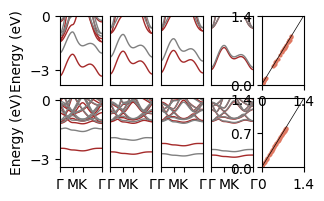

(0.0, 1.4)

In [52]:
cm = 1/2.54
figure(figsize=(8*cm, 5*cm))

color_up ="brown"
color_dn = "grey"
subplot_params = [2, 4, 1]

subplot(2, 5, 1)
plot_bands("$bn22bc_dir/Doping/BN22BCbands-0.0.eigenvals", spin=2, color_up = color_up, color_dn=color_dn, linewidth=1)
ylim(Fermi_Levels_bn22bc[1]+2.5,  Fermi_Levels_bn22bc[1] +6)
xticks([])
yticks([-3, 0])

xlabel("")

subplot(2, 5, 2)
xlabel("")

plot_bands("$bn22bc_dir/Doping/BN22BCbands--0.4.eigenvals",color_up = color_up, color_dn=color_dn,  spin=2, linewidth=1)
yticks([])
ylabel("")
xlabel("")
xticks([])

ylim(Fermi_Levels_bn22bc[2]+2.5,  Fermi_Levels_bn22bc[2] +6)
subplot(2, 5, 4)
plot_bands("$bn22bc_dir/Doping/BN22BCbands--0.8.eigenvals",color_up = color_up, color_dn=color_dn,  spin=2, linewidth=1)
yticks([])
ylim(Fermi_Levels_bn22bc[4]+2.5,  Fermi_Levels_bn22bc[4] +6)
xlabel("")
xticks([])


ylabel("")
subplot(2, 5, 3)
plot_bands("$bn22bc_dir/Doping/BN22BCbands--0.6.eigenvals",color_up = color_up, color_dn=color_dn,  spin=2, linewidth=1)
yticks([])
ylabel("")
xlabel("")
ylim(Fermi_Levels_bn22bc[3]+2.5,  Fermi_Levels_bn22bc[3] +6)
xticks([])

subplot(2, 5, 6)
plot_bands("$bn44bc_dir/Doping/BN44BCbands-0.0.eigenvals", color_up = color_up, color_dn=color_dn, spin=2, linewidth=1)
ylim(Fermi_Levels_bn44bc[1]+2.5,  Fermi_Levels_bn44bc[1] +6)
xlabel("")
yticks([-3, 0])

subplot(2, 5, 7)
plot_bands("$bn44bc_dir/Doping/BN44BCbands--0.4.eigenvals", color_up = color_up, color_dn=color_dn, spin=2, linewidth=1)
ylim(Fermi_Levels_bn44bc[2]+2.5,  Fermi_Levels_bn44bc[2] +6)
yticks([])
ylabel("")
xlabel("")

subplot(2, 5, 8)
plot_bands("$bn44bc_dir/Doping/BN44BCbands--0.6.eigenvals", color_up = color_up, color_dn=color_dn, spin=2, linewidth=1)
ylim(Fermi_Levels_bn44bc[3]+2.5,  Fermi_Levels_bn44bc[3] +6)
yticks([])
ylabel("")
xlabel("")

subplot(2, 5, 9)
plot_bands("$bn44bc_dir/Doping/BN44BCbands--0.8.eigenvals", color_up = color_up, color_dn=color_dn, spin=2, linewidth=1)
ylim(Fermi_Levels_bn44bc[4]+2.5,  Fermi_Levels_bn44bc[4] +6)
yticks([])
ylabel("")
xlabel("")


subplot(2, 5, 10)

scatter(bn44bc_splits_lda_cnone, bn44bc_x_n_lda_cnone, label="Slater Exchange without Correlation", color=lda_cnone_color, s=dot_size)

plot(x, x, color="black", linewidth=linewidth)
xticks([0, 1.4], ["0", "1.4"], size=label_size)
yticks([0, 0.7, 1.4], size=label_size);
ylim(0, 1.4)
xlim(0, 1.4)

subplot(2, 5, 5)

scatter(bn22bc_splits_lda_cnone, bn22bc_x_n_lda_cnone, label="Slater Exchange without Correlation", color=lda_cnone_color, s=dot_size)

plot(x, x, color="black", linewidth=linewidth)
xticks([0, 1.4], ["0", "1.4"], size=label_size)
yticks([0, 1.4], size=label_size);
ylim(0, 1.4)
xlim(0, 1.4)
savefig("Doping-bands.pdf")
xlim()
